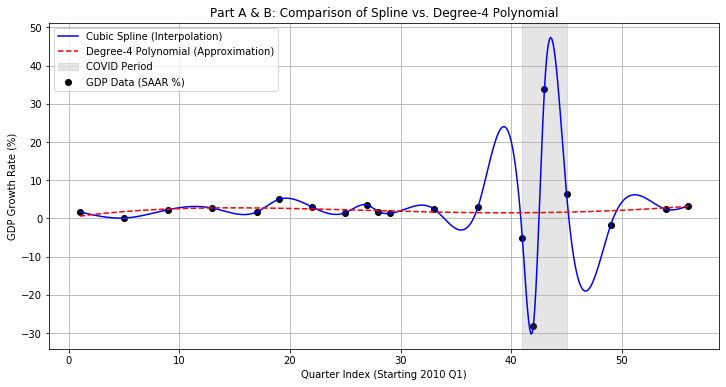

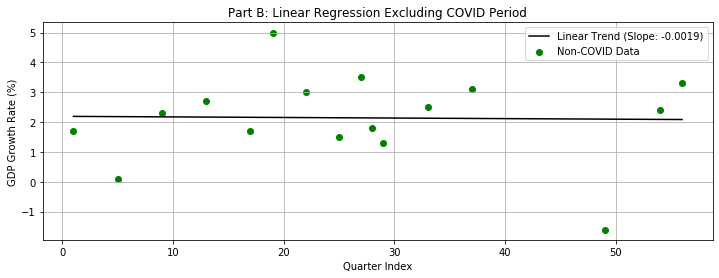

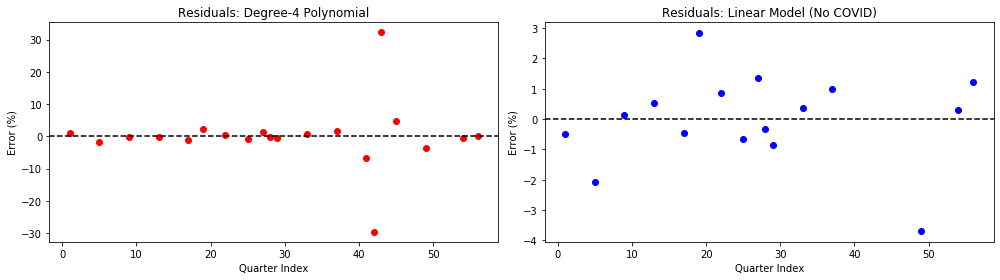

PART B DIAGNOSTICS
Degree-4 Poly Condition Number: 3.31e+14
Degree-4 Poly RMSE: 10.0314
Linear Model Slope (Excl. COVID): -0.0019

CONTINUITY VERIFICATION AT X = 28
C0 (Value): Left=1.8000, Right=1.8000
C1 (Slope): Left=-1.4987, Right=-1.4987
C2 (Curvature): Left=2.4213, Right=2.4213


In [8]:
import numpy as np
import matplotlib.pyplot as plt


# DATASET INITIALIZATION

# Using consecutive integer quarter indices as x-values
# Data points
x_data = np.array([1, 5, 9, 13, 17, 19, 22, 25, 27, 28, 29, 33, 37, 41, 42, 43, 45, 49, 54, 56])
y_data = np.array([1.7, 0.1, 2.3, 2.7, 1.7, 5.0, 3.0, 1.5, 3.5, 1.8, 1.3, 2.5, 3.1, -5.1, -28.1, 33.8, 6.3, -1.6, 2.4, 3.3])


# PART A: NATURAL CUBIC SPLINE INTERPOLATION

# Thomas Algorithm to solve the tridiagonal system of size (n-2)x(n-2)

def solve_natural_cubic_spline(x, y):
   
    n = len(x)
    h = np.diff(x)  # Step sizes
    
    # Setup tridiagonal system matrices for internal second derivatives
    num_internal = n - 2
    A_diag = np.zeros(num_internal - 1)  # Sub-diagonal
    B_diag = np.zeros(num_internal)      # Main diagonal
    C_diag = np.zeros(num_internal - 1)  # Super-diagonal
    D_vec = np.zeros(num_internal)       # RHS vector
    
    for i in range(1, n - 1):
        idx = i - 1
        B_diag[idx] = 2 * (h[i-1] + h[i])
        D_vec[idx] = 6 * ((y[i+1] - y[i])/h[i] - (y[i] - y[i-1])/h[i-1])
        if idx > 0:
            A_diag[idx-1] = h[i-1]
        if idx < num_internal - 1:
            C_diag[idx] = h[i]
            
    # Thomas Algorithm (Forward Elimination)
    for i in range(1, num_internal):
        w = A_diag[i-1] / B_diag[i-1]
        B_diag[i] = B_diag[i] - w * C_diag[i-1]
        D_vec[i] = D_vec[i] - w * D_vec[i-1]
    
    # Back Substitution
    M_internal = np.zeros(num_internal)
    M_internal[-1] = D_vec[-1] / B_diag[-1]
    for i in range(num_internal - 2, -1, -1):
        M_internal[i] = (D_vec[i] - C_diag[i] * M_internal[i+1]) / B_diag[i]
        
    # Natural Boundary Conditions: M1 = Mn = 0
    M = np.zeros(n)
    M[1:-1] = M_internal
    return M, h

# Evaluates the spline at requested points using the cubic piece formula
def evaluate_spline(x_data, y_data, M, h, x_eval):
    y_eval = []
    for val in x_eval:
        i = np.searchsorted(x_data, val) - 1
        i = max(0, min(i, len(x_data) - 2))
        dx = val - x_data[i]
        # Calculate coefficients for interval i
        a_i = y_data[i]
        b_i = (y_data[i+1] - y_data[i])/h[i] - h[i]*(2*M[i] + M[i+1])/6
        c_i = M[i] / 2
        d_i = (M[i+1] - M[i]) / (6 * h[i])
        y_eval.append(a_i + b_i*dx + c_i*(dx**2) + d_i*(dx**3))
    return np.array(y_eval)


# PART B: POLYNOMIAL AND LEAST SQUARES

# Fits a polynomial using the Normal Equations: (A.T @ A) * c = A.T @ y

def fit_least_squares(x, y, degree):
   
    # Build Vandermonde Matrix manually
    A = np.vander(x, degree + 1, increasing=True)
    
    # Solve Normal Equations
    ATA = A.T @ A
    ATy = A.T @ y
    
    # Check Condition Number
    cond_num = np.linalg.cond(ATA)
    coeffs = np.linalg.solve(ATA, ATy)
    
    return coeffs, cond_num, A


# MAIN EXECUTION AND CALCULATIONS

# 1. Cubic Spline
M, h_diff = solve_natural_cubic_spline(x_data, y_data)
x_smooth = np.linspace(1, 56, 500)
y_spline = evaluate_spline(x_data, y_data, M, h_diff, x_smooth)

# 2. Degree-4 Polynomial Fit
coeffs_p4, cond_p4, A_p4_train = fit_least_squares(x_data, y_data, 4)
y_poly4_smooth = np.vander(x_smooth, 5, increasing=True) @ coeffs_p4
y_poly4_train = A_p4_train @ coeffs_p4
res_poly4 = y_data - y_poly4_train
rmse_poly4 = np.sqrt(np.mean(res_poly4**2))

# 3. Linear Model (Excluding COVID: 2020 Q1 to 2021 Q1)
# Quarters to exclude: Index 41 (2020 Q1) through 45 (2021 Q1)
mask = (x_data < 41) | (x_data > 45)
x_lin = x_data[mask]
y_lin = y_data[mask]
coeffs_lin, _, A_lin_train = fit_least_squares(x_lin, y_lin, 1)
y_lin_smooth = np.vander(x_smooth, 2, increasing=True) @ coeffs_lin
res_lin = y_lin - (A_lin_train @ coeffs_lin)


# VISUALIZATION

# Figure 1: Main Model Comparison
plt.figure(figsize=(12, 6))
plt.scatter(x_data, y_data, color='black', label='GDP Data (SAAR %)')
plt.plot(x_smooth, y_spline, 'b-', label='Cubic Spline (Interpolation)')
plt.plot(x_smooth, y_poly4_smooth, 'r--', label='Degree-4 Polynomial (Approximation)')
plt.axvspan(41, 45, color='gray', alpha=0.2, label='COVID Period')
plt.title('Part A & B: Comparison of Spline vs. Degree-4 Polynomial')
plt.xlabel('Quarter Index (Starting 2010 Q1)')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.grid(True)

# Figure 2: Linear Trend (Non-COVID)
plt.figure(figsize=(12, 4))
plt.scatter(x_lin, y_lin, color='green', label='Non-COVID Data')
plt.plot(x_smooth, y_lin_smooth, 'k-', label=f'Linear Trend (Slope: {coeffs_lin[1]:.4f})')
plt.title('Part B: Linear Regression Excluding COVID Period')
plt.xlabel('Quarter Index')
plt.ylabel('GDP Growth Rate (%)')
plt.legend()
plt.grid(True)

# Figure 3: Mandatory Residual Plots 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.scatter(x_data, res_poly4, color='red')
ax1.axhline(0, color='black', linestyle='--')
ax1.set_title('Residuals: Degree-4 Polynomial')
ax1.set_xlabel('Quarter Index')
ax1.set_ylabel('Error (%)')

ax2.scatter(x_lin, res_lin, color='blue')
ax2.axhline(0, color='black', linestyle='--')
ax2.set_title('Residuals: Linear Model (No COVID)')
ax2.set_xlabel('Quarter Index')
ax2.set_ylabel('Error (%)')

plt.tight_layout()
plt.show()


# CONTEXTUAL OUTPUTS FOR REPORT

print(f"PART B DIAGNOSTICS")
print(f"Degree-4 Poly Condition Number: {cond_p4:.2e}")
print(f"Degree-4 Poly RMSE: {rmse_poly4:.4f}")
print(f"Linear Model Slope (Excl. COVID): {coeffs_lin[1]:.4f}")


# CONTINUITY VERIFICATION TEST

def verify_continuity(idx):
    # Testing at knot x_data[idx]
    # 'Left' piece is interval idx-1, 'Right' piece is interval idx
    
    # Left Piece Coefficients (i = idx-1)
    i_L = idx - 1
    h_L = h_diff[i_L]
    b_L = (y_data[i_L+1] - y_data[i_L])/h_L - h_L*(2*M[i_L] + M[i_L+1])/6
    c_L = M[i_L] / 2
    d_L = (M[i_L+1] - M[i_L]) / (6 * h_L)
    
    # Right Piece Coefficients (i = idx)
    i_R = idx
    h_R = h_diff[i_R]
    b_R = (y_data[i_R+1] - y_data[i_R])/h_R - h_R*(2*M[i_R] + M[i_R+1])/6
    c_R = M[i_R] / 2

    # Calculations at the knot (dx = h_L for left piece, dx = 0 for right piece)
    val_L = y_data[i_L] + b_L*h_L + c_L*(h_L**2) + d_L*(h_L**3)
    slope_L = b_L + 2*c_L*h_L + 3*d_L*(h_L**2)
    curv_L = 2*c_L + 6*d_L*h_L

    val_R = y_data[i_R] # a_R
    slope_R = b_R
    curv_R = 2*c_R

    print(f"\nCONTINUITY VERIFICATION AT X = {x_data[idx]}")
    print(f"C0 (Value): Left={val_L:.4f}, Right={val_R:.4f}")
    print(f"C1 (Slope): Left={slope_L:.4f}, Right={slope_R:.4f}")
    print(f"C2 (Curvature): Left={curv_L:.4f}, Right={curv_R:.4f}")

# Verify at an arbitrary interior knot (Index 9 where x=28)
verify_continuity(9)